# Chronos 2 Foundation Model: Zero-Shot Forecasting

This notebook introduces Amazon's Chronos 2, a foundation model for probabilistic time series forecasting.

**What makes Chronos 2 special:**
- Pre-trained on diverse time series datasets
- Zero-shot capable (no training required!)
- Probabilistic forecasts with quantile predictions
- Built on language model techniques for time series

In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.datasets import AirPassengersDataset, EnergyDataset
from darts.models import ChronosModel, ExponentialSmoothing
from darts.metrics import mape

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md
The `XGBoost` module could not be imported. To enable XGBoost support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


## Load Data

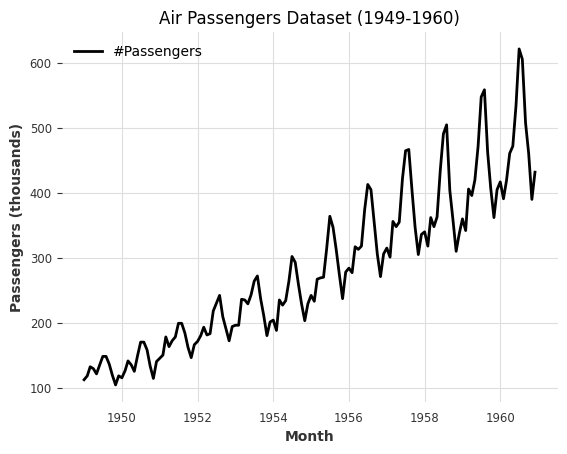

In [3]:
# Load classic time series dataset
series = AirPassengersDataset().load()
train, val = series.split_before(0.8)

# Visualize
series.plot()
plt.title("Air Passengers Dataset (1949-1960)")
plt.ylabel("Passengers (thousands)")
plt.show()

## 1. Zero-Shot Forecasting: No Training Required!

Foundation models are **pre-trained** on massive datasets. You can use them immediately without fit()!

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Zero-shot MAPE: 5.96%


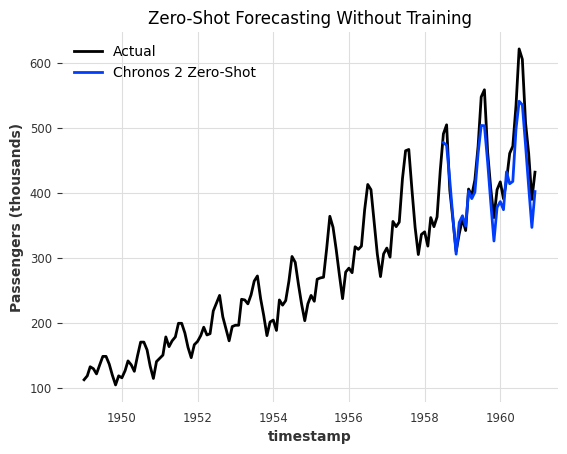

In [4]:
# Initialize Chronos 2 with reduced context for Air Passengers dataset
# Air Passengers has 144 points; we want to backtest at start=0.75 (108 points)
# context_length=96 is the minimum we'll enforce (0.75 × 144 ≈ 108, rounded to patch_size=16)
# This becomes the MINIMUM context length this model instance will accept
model = ChronosModel(context_length=96)

# Predict WITHOUT calling fit()!
forecast = model.predict(n=len(val), series=train)

# Evaluate
error = mape(val, forecast)
print(f"Zero-shot MAPE: {error:.2f}%")

# Plot
series.plot(label="Actual")
forecast.plot(label="Chronos 2 Zero-Shot")
plt.title("Zero-Shot Forecasting Without Training")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.show()

## 2. Probabilistic Forecasting with Quantiles

Unlike deterministic models, Chronos 2 provides **probabilistic forecasts** with uncertainty quantification.

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


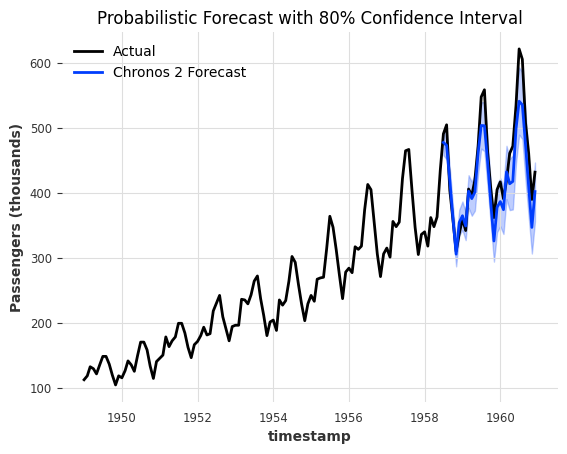

In [5]:
# Generate probabilistic forecast
prob_forecast = model.predict(n=len(val), series=train, num_samples=100)

# Plot with confidence intervals
series.plot(label="Actual")
prob_forecast.plot(
    label="Chronos 2 Forecast",
    low_quantile=0.1,
    high_quantile=0.9
)
plt.title("Probabilistic Forecast with 80% Confidence Interval")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.show()

## 3. Comparing with Traditional Models

Let's see how Chronos 2 compares to a traditional model that requires training.

Chronos 2 (zero-shot):  5.96%
Traditional (trained):  8.10%


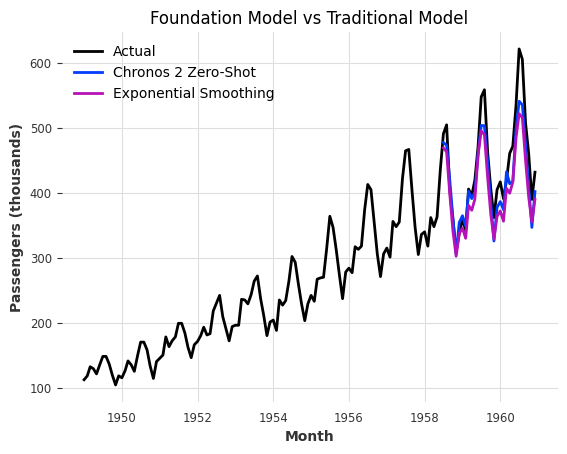

In [6]:
# Traditional model requires fit()
trad_model = ExponentialSmoothing()
trad_model.fit(train)
trad_forecast = trad_model.predict(len(val))

trad_error = mape(val, trad_forecast)

print(f"Chronos 2 (zero-shot):  {error:.2f}%")
print(f"Traditional (trained):  {trad_error:.2f}%")

# Plot both
series.plot(label="Actual")
forecast.plot(label="Chronos 2 Zero-Shot")
trad_forecast.plot(label="Exponential Smoothing")
plt.title("Foundation Model vs Traditional Model")
plt.ylabel("Passengers (thousands)")
plt.legend()
plt.show()

### Understanding Zero-Shot Performance

**Key Observation:** Chronos 2 delivers competitive performance despite **never seeing this series before**!

**Why does Chronos 2 work in zero-shot mode?**
- Pre-trained on diverse time series datasets
- Uses language model techniques (attention mechanisms)
- Learns universal temporal patterns (seasonality, trends)
- Provides uncertainty estimates through probabilistic forecasting

**When does Chronos 2 shine?**
- Cold start: New products/services with no history
- Batch forecasting: Thousands of diverse series
- Uncertainty quantification: Need confidence intervals
- Quick prototyping: Immediate forecasts without tuning

**When to use traditional models?**
- Domain expertise can be encoded (business rules)
- Explainability requirements
- Very long historical data with local patterns

## 4. Batch Forecasting on Multiple Series

Foundation models can forecast multiple series efficiently.

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


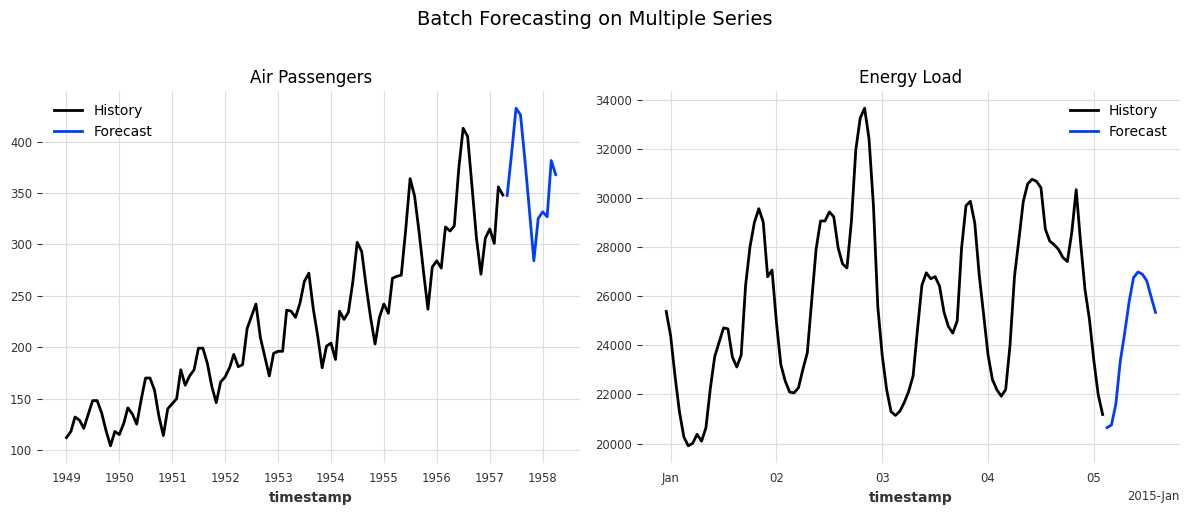

In [7]:
# Load multiple series
energy = EnergyDataset().load()
# Select univariate components from multivariate energy dataset
series_list = [series[:100], energy["total load actual"][:100]]

# Forecast all series
forecasts = []
for s in series_list:
    f = model.predict(n=12, series=s)
    forecasts.append(f)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
titles = ["Air Passengers", "Energy Load"]
for idx, (s, f, title) in enumerate(zip(series_list, forecasts, titles)):
    ax = axes[idx]
    s.plot(ax=ax, label="History")
    f.plot(ax=ax, label="Forecast")
    ax.set_title(title)
    ax.legend()
plt.suptitle("Batch Forecasting on Multiple Series", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Backtesting: Validating Performance Over Time

Backtesting evaluates how the model would have performed historically by:
1. Making forecasts at multiple past time points
2. Comparing each forecast to what actually happened
3. Measuring consistency of performance

This shows whether the model is reliable across different conditions.

In [8]:
# For backtesting, we call fit() once (API compatibility)
# This satisfies Darts' sanity checks but doesn't train the model
model.fit(series)

# Backtest: Generate multiple 12-month forecasts
historical_forecasts = model.historical_forecasts(
    series=series,
    start=0.75,           # Start after sufficient context
    forecast_horizon=12,
    stride=6,
    retrain=False,        # No retraining needed for zero-shot!
    last_points_only=False
)

# Calculate MAPE for each forecast window
print(f"Backtesting Results ({len(historical_forecasts)} forecast windows):\n")
mapes = []
for i, forecast in enumerate(historical_forecasts):
    actual = series[forecast.start_time():forecast.end_time()]
    error = mape(actual, forecast)
    mapes.append(error)
    start_date = forecast.start_time()
    print(f"  Forecast {i+1} (starting {start_date}): {error:.2f}% MAPE")

avg_error = sum(mapes) / len(mapes)
print(f"\nAverage MAPE across all windows: {avg_error:.2f}%")

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argu

Backtesting Results (5 forecast windows):

  Forecast 1 (starting 1957-12-01 00:00:00): 6.45% MAPE
  Forecast 2 (starting 1958-06-01 00:00:00): 3.37% MAPE
  Forecast 3 (starting 1958-12-01 00:00:00): 3.01% MAPE
  Forecast 4 (starting 1959-06-01 00:00:00): 3.82% MAPE
  Forecast 5 (starting 1959-12-01 00:00:00): 2.50% MAPE

Average MAPE across all windows: 3.83%


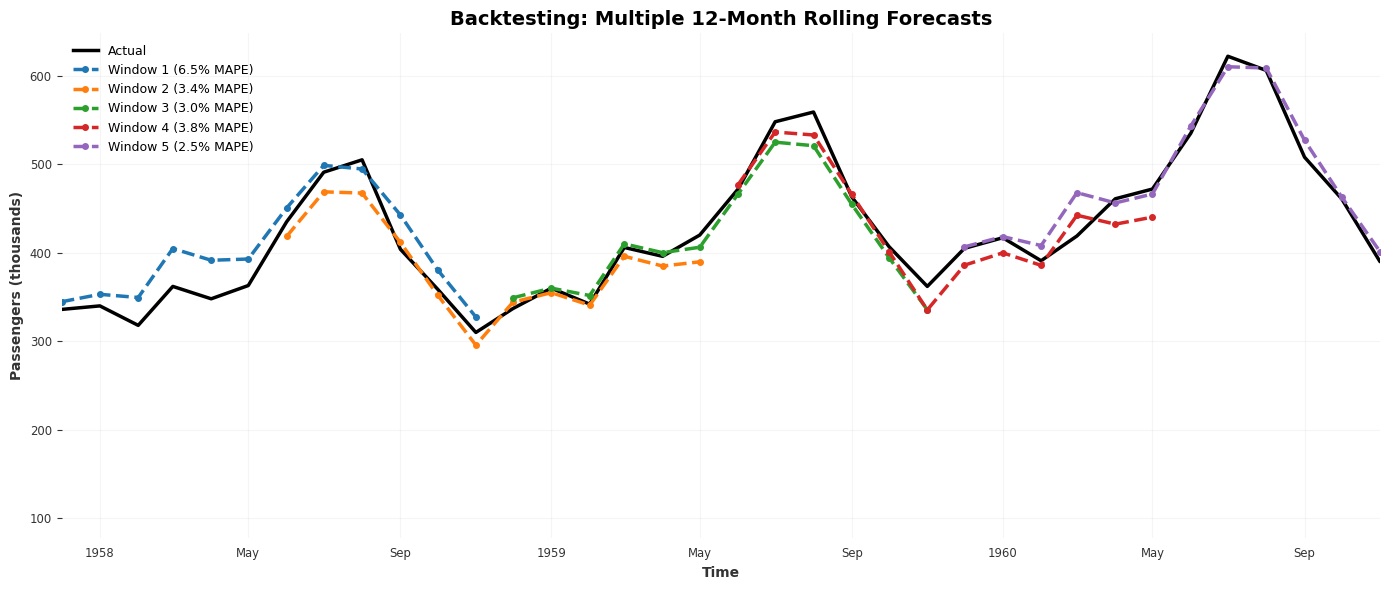

In [9]:
# Visualize: Single timeline with all forecast windows
fig, ax = plt.subplots(figsize=(14, 6))

# Plot actual data
series.plot(ax=ax, label="Actual", linewidth=2.5, color='black')

# Distinct colors using tab10 palette
colors = plt.cm.tab10.colors

# Plot each forecast window with dashed line
for i, forecast in enumerate(historical_forecasts):
    forecast.plot(
        ax=ax,
        label=f"Window {i+1} ({mapes[i]:.1f}% MAPE)",
        linewidth=2.5,
        color=colors[i],
        linestyle='--',
        marker='o',
        markersize=4
    )

# Zoom into the forecasting region
first_forecast_start = historical_forecasts[0].start_time()
last_forecast_end = historical_forecasts[-1].end_time()
ax.set_xlim(first_forecast_start, last_forecast_end)

ax.set_title("Backtesting: Multiple 12-Month Rolling Forecasts", fontsize=14, fontweight='bold')
ax.set_ylabel("Passengers (thousands)")
ax.set_xlabel("Time")
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What This Shows

**Backtesting simulates production deployment**
This approach mirrors real-world usage: a fixed model making rolling 12-month forecasts as new data arrives. With `retrain=False`, the model incorporates new observations as context without updating its weights.

**Overlapping forecasts show model behavior**
Each dashed colored line represents a 12-month forecast. Where forecasts overlap, you can see how the model performs on the same time period from different starting points. The MAPE variation shows performance across different conditions.

**What the results indicate:**
- Model performs consistently across tested windows
- Forecasts track actual trends (dashed lines follow black actual line)
- Uncertainty estimates help quantify forecast reliability

**Production implications:** This backtesting demonstrates the model's behavior when deployed with rolling forecasts. The model doesn't require retraining - it uses new observations as context for subsequent forecasts.

## 6. Understanding Probabilistic Forecasts

Chronos 2's probabilistic forecasts provide multiple quantiles, allowing you to assess forecast uncertainty.

/Users/nehalecky/Projects/darts/.worktrees/chronos-2-integration/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


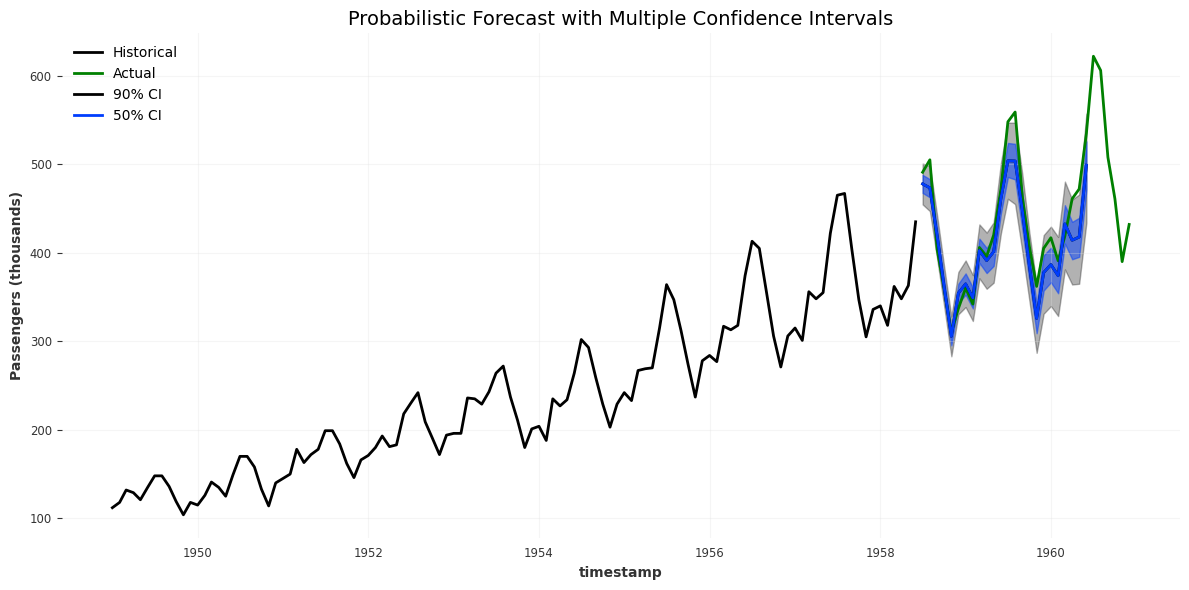

In [10]:
# Generate forecast with multiple samples
prob_forecast = model.predict(n=24, series=train, num_samples=200)

# Plot different confidence levels
fig, ax = plt.subplots(figsize=(12, 6))

# Historical data
train.plot(ax=ax, label="Historical", color='black', linewidth=2)
val.plot(ax=ax, label="Actual", color='green', linewidth=2)

# 90% confidence interval
prob_forecast.plot(
    ax=ax,
    label="90% CI",
    low_quantile=0.05,
    high_quantile=0.95,
    alpha=0.3
)

# 50% confidence interval (more likely range)
prob_forecast.plot(
    ax=ax,
    label="50% CI",
    low_quantile=0.25,
    high_quantile=0.75,
    alpha=0.5
)

ax.set_title("Probabilistic Forecast with Multiple Confidence Intervals", fontsize=14)
ax.set_ylabel("Passengers (thousands)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpreting Confidence Intervals

**50% Confidence Interval (darker shading):**
- The model expects the true value to fall in this range half the time
- Useful for "most likely" scenarios
- Narrower interval = higher confidence in specific outcomes

**90% Confidence Interval (lighter shading):**
- The model expects the true value to fall in this range 90% of the time
- Useful for risk management and planning
- Wider interval = accounting for more uncertainty

**Why probabilistic forecasts matter:**
- **Risk assessment**: Plan for best/worst case scenarios
- **Decision making**: Different actions for different probability levels
- **Uncertainty quantification**: Know when forecasts are less reliable
- **Anomaly detection**: Values outside intervals may be unusual

## Key Takeaways

1. **Zero-Shot Power**: Foundation models work immediately without training
2. **Probabilistic Forecasts**: Uncertainty quantification through quantile predictions
3. **Language Model Techniques**: Chronos applies transformer architectures to time series
4. **Limited Data**: Excel when you have little historical data
5. **Darts Integration**: Works seamlessly with existing Darts workflows
6. **Univariate Focus**: Current version supports single time series (multivariate in future)

**Resources:**
- [Chronos Paper](https://arxiv.org/abs/2403.07815) - "Chronos: Learning the Language of Time Series"
- [Chronos GitHub](https://github.com/amazon-science/chronos-forecasting)
- [HuggingFace Model](https://huggingface.co/amazon/chronos-2)
- [Darts Foundation Models Guide](../docs/userguide/foundation_models.md)